# Project 2 — Safety Stock Classification Engine

**Main question:** How much uncertainty buffer does each SKU-location need?

**System flow:** `Forecast Accuracy → [Project 2] → Reorder Point → Fill Rate → Monetization → ROI`

---

## Sections
1. Load data and Project 1 error metrics
2. Compute demand and lead-time uncertainty per SKU-location
3. Calculate recommended safety stock (formula-based)
4. Compare recommended vs current safety stock
5. Segment safety stock by ABC/XYZ class
6. Service level vs working capital trade-off
7. Business summary and recommendations

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

from src.inventory import safety_stock_normal, safety_stock_simple, days_on_hand
from src.utils import abc_classify, xyz_classify

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.2f}".format)

# Use processed (real) data if available, else fall back to sample (synthetic)
_processed = ROOT / "data" / "processed" / "master_data.csv"
_sample    = ROOT / "data" / "sample"    / "master_data.csv"
DATA = _processed if _processed.exists() else _sample
print(f"Data source: {DATA.relative_to(ROOT)}")
P1   = ROOT / "outputs" / "tables" / "01_forecast_accuracy_results.csv"
OUT  = ROOT / "outputs"
FIG  = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

print("Root:", ROOT)

Data source: data\processed\master_data.csv
Root: C:\Users\simba\OneDrive\Dokumenter\Dev\supply-chain-uncertainty-system


---
## 1. Load data and Project 1 error metrics

In [2]:
df = pd.read_csv(DATA, parse_dates=["date"])
p1 = pd.read_csv(P1)

print(f"Master data: {len(df):,} rows")
print(f"Project 1 results: {len(p1)} SKU-locations")

# Keep only clean weeks (no promo / holiday)
df_clean = df[(df["promo_flag"] == 0) & (df["holiday_flag"] == 0)].copy()
df_clean.head(2)

Master data: 46,800 rows
Project 1 results: 300 SKU-locations


,sku,location,date,actual_demand,forecast,abc_class,xyz_class,cv,promo_flag,holiday_flag,...,unit_margin,holding_cost_rate,shortage_cost_per_unit,service_target,safety_stock,reorder_point,on_hand,on_order,stockout_flag,product_family
2,SKU_A01,Store_Central,2022-01-17,246,199,A,X,0.36,0,0,...,0.38,0.20,0.57,0.95,111.00,301.00,131.00,53.00,1,DAIRY
3,SKU_A01,Store_Central,2022-01-24,290,209,A,X,0.36,0,0,...,0.38,0.20,0.57,0.95,111.00,301.00,208.00,58.00,1,DAIRY


---
## 2. Compute demand and lead-time uncertainty per SKU-location

In [3]:
def sku_stats(grp: pd.DataFrame) -> pd.Series:
    d = grp["actual_demand"].values
    return pd.Series({
        "avg_demand":       d.mean(),
        "std_demand":       d.std(),
        "cv":               d.std() / d.mean() if d.mean() > 0 else 0,
        "lead_time_mean":   grp["lead_time_mean"].iloc[0],
        "lead_time_std":    grp["lead_time_std"].iloc[0],
        "unit_cost":        grp["unit_cost"].iloc[0],
        "holding_cost_rate":grp["holding_cost_rate"].iloc[0],
        "service_target":   grp["service_target"].iloc[0],
        "current_ss":       grp["safety_stock"].iloc[0],
        "abc_class":        grp["abc_class"].iloc[0],
        "xyz_class":        grp["xyz_class"].iloc[0],
    })

stats = (
    df_clean
    .groupby(["sku", "location"])
    .apply(sku_stats, include_groups=False)
    .reset_index()
)

stats["segment"] = stats["abc_class"] + "/" + stats["xyz_class"]
print(f"{len(stats)} SKU-location rows computed")
stats.head(3)

300 SKU-location rows computed

,sku,location,avg_demand,std_demand,cv,lead_time_mean,lead_time_std,unit_cost,holding_cost_rate,service_target,current_ss,abc_class,xyz_class,segment
0,SKU_A01,Store_Central,259.62,50.49,0.19,5,1,1.25,0.20,0.95,111.00,A,X,A/X
1,SKU_A01,Store_East,156.00,28.83,0.18,10,2,1.25,0.20,0.95,99.00,A,X,A/X
2,SKU_A01,Store_North,229.21,40.16,0.18,7,1,1.25,0.20,0.95,115.00,A,X,A/X


---
## 3. Calculate recommended safety stock

Formula (normally distributed demand and lead time):

$$SS = Z \cdot \sqrt{LT \cdot \sigma_d^2 + \bar{d}^2 \cdot \sigma_{LT}^2}$$

Where:
- $Z$ = service-level z-score (e.g. 1.645 for 95% CSL)
- $LT$ = average lead time in weeks
- $\sigma_d$ = weekly demand std dev
- $\bar{d}$ = average weekly demand
- $\sigma_{LT}$ = lead time std dev (in weeks)

In [4]:
LT_DAYS_PER_WEEK = 7.0

def compute_ss_row(row: pd.Series) -> float:
    lt_weeks = row["lead_time_mean"] / LT_DAYS_PER_WEEK
    lt_std_weeks = row["lead_time_std"] / LT_DAYS_PER_WEEK
    return safety_stock_normal(
        sigma_demand=row["std_demand"],
        lead_time=lt_weeks,
        sigma_lead_time=lt_std_weeks,
        avg_demand=row["avg_demand"],
        service_level=row["service_target"],
    )

stats["rec_ss"] = stats.apply(compute_ss_row, axis=1).round(0)

# Working capital in safety stock
stats["current_ss_chf"] = stats["current_ss"] * stats["unit_cost"]
stats["rec_ss_chf"]     = stats["rec_ss"]     * stats["unit_cost"]
stats["ss_delta_units"]  = stats["rec_ss"] - stats["current_ss"]
stats["ss_delta_chf"]    = stats["rec_ss_chf"] - stats["current_ss_chf"]

# Flag over/under-stocked
def ss_flag(delta: float) -> str:
    if delta > 10:
        return "Under-buffered"
    elif delta < -10:
        return "Over-buffered"
    return "On target"

stats["ss_status"] = stats["ss_delta_units"].apply(ss_flag)

print("Buffer status:")
print(stats["ss_status"].value_counts())
print()
total_current = stats["current_ss_chf"].sum()
total_rec     = stats["rec_ss_chf"].sum()
print(f"Current SS working capital:     CHF {total_current:>10,.0f}")
print(f"Recommended SS working capital: CHF {total_rec:>10,.0f}")
print(f"Net change:                     CHF {total_rec - total_current:>+10,.0f}")

Buffer status:
ss_status
On target        280
Over-buffered     20
Name: count, dtype: int64

Current SS working capital:     CHF     31,957
Recommended SS working capital: CHF     30,002
Net change:                     CHF     -1,955


---
## 4. Compare recommended vs current safety stock

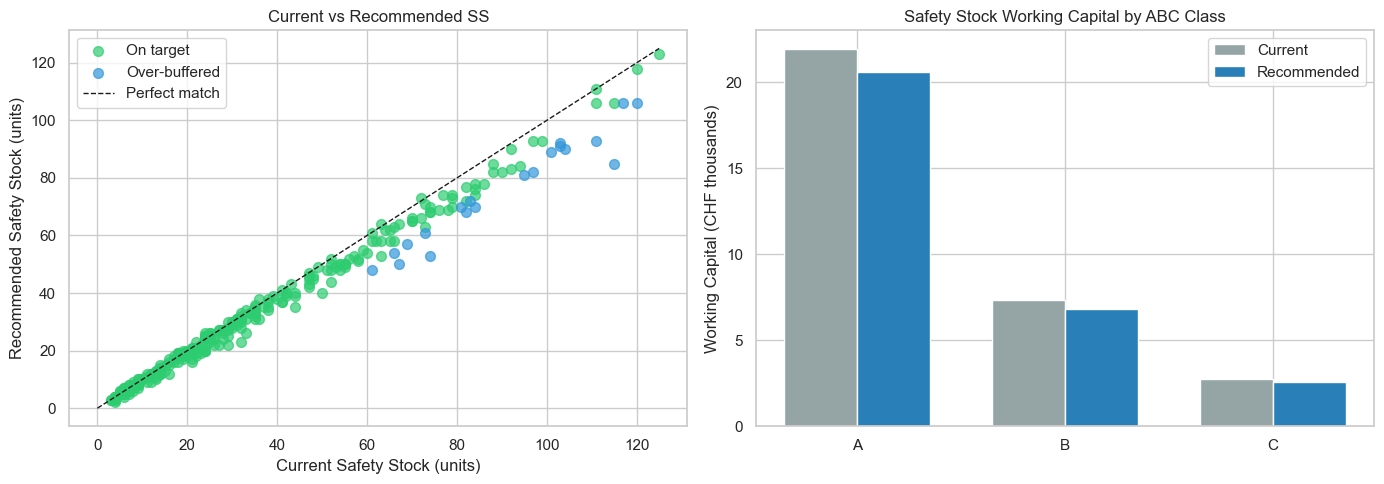

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: current vs recommended
colors_map = {"Under-buffered": "#e74c3c", "Over-buffered": "#3498db", "On target": "#2ecc71"}
for status, grp in stats.groupby("ss_status"):
    axes[0].scatter(grp["current_ss"], grp["rec_ss"],
                    label=status, color=colors_map[status], alpha=0.7, s=50)

lim = max(stats[["current_ss", "rec_ss"]].max())
axes[0].plot([0, lim], [0, lim], "k--", linewidth=1, label="Perfect match")
axes[0].set_xlabel("Current Safety Stock (units)")
axes[0].set_ylabel("Recommended Safety Stock (units)")
axes[0].set_title("Current vs Recommended SS")
axes[0].legend()

# Bar: working capital by ABC class
wc = stats.groupby("abc_class")[["current_ss_chf", "rec_ss_chf"]].sum() / 1000
x = range(len(wc))
w = 0.35
axes[1].bar([i - w/2 for i in x], wc["current_ss_chf"], w, label="Current",     color="#95a5a6")
axes[1].bar([i + w/2 for i in x], wc["rec_ss_chf"],     w, label="Recommended", color="#2980b9")
axes[1].set_xticks(x)
axes[1].set_xticklabels(wc.index)
axes[1].set_ylabel("Working Capital (CHF thousands)")
axes[1].set_title("Safety Stock Working Capital by ABC Class")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG / "02a_ss_comparison.png", dpi=150)
plt.show()

---
## 5. Segment safety stock by ABC/XYZ class

In [6]:
seg_summary = (
    stats.groupby("segment")
    .agg(
        n=("sku", "count"),
        avg_current_ss=("current_ss", "mean"),
        avg_rec_ss=("rec_ss", "mean"),
        total_current_chf=("current_ss_chf", "sum"),
        total_rec_chf=("rec_ss_chf", "sum"),
        service_target=("service_target", "mean"),
    )
    .round(0)
    .sort_values("total_current_chf", ascending=False)
)
seg_summary["wc_change_chf"] = seg_summary["total_rec_chf"] - seg_summary["total_current_chf"]
seg_summary

,n,avg_current_ss,avg_rec_ss,total_current_chf,total_rec_chf,service_target,wc_change_chf
segment,,,,,,,
A/X,95,69.00,63.00,11404.00,10539.00,1.00,-865.00
A/Y,65,38.00,36.00,9373.00,8960.00,1.00,-413.00
B/Z,40,13.00,12.00,4404.00,4133.00,1.00,-271.00
B/Y,40,25.00,23.00,2906.00,2697.00,1.00,-209.00
C/Z,50,6.00,6.00,2567.00,2414.00,1.00,-153.00
A/Z,5,19.00,18.00,1128.00,1080.00,1.00,-48.00
C/Y,5,9.00,9.00,175.00,179.00,1.00,4.00


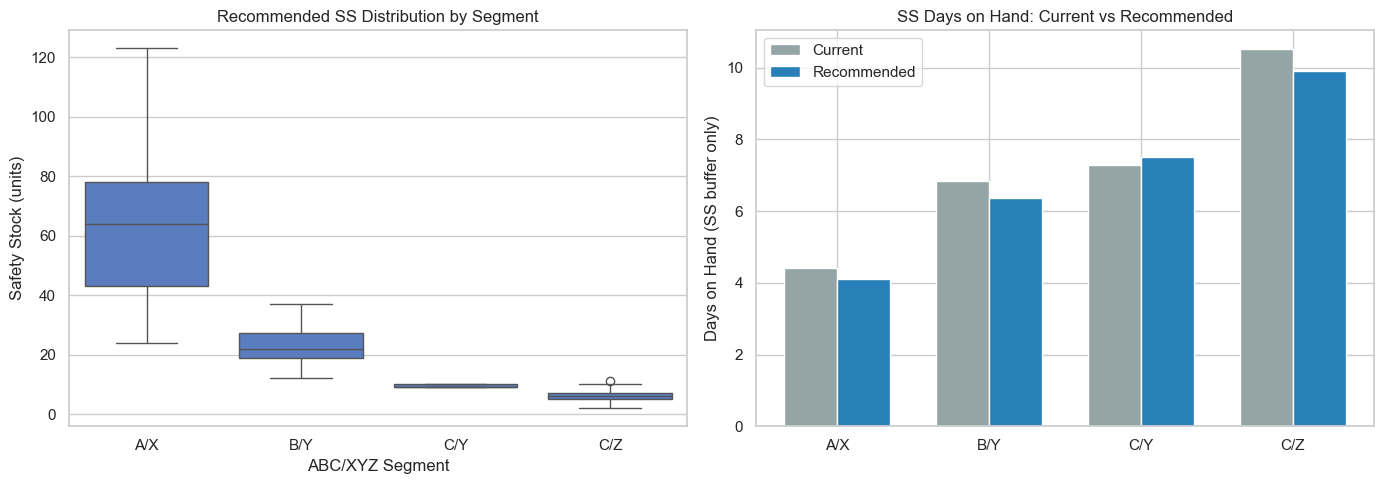

In [7]:
# Days on hand comparison
stats["doh_current"] = stats.apply(
    lambda r: (r["current_ss"] / r["avg_demand"]) * 7 if r["avg_demand"] > 0 else 0, axis=1
)
stats["doh_rec"] = stats.apply(
    lambda r: (r["rec_ss"] / r["avg_demand"]) * 7 if r["avg_demand"] > 0 else 0, axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: recommended SS by segment using seaborn
order = ["A/X", "B/X", "B/Y", "C/Y", "C/Z"]
order = [s for s in order if s in stats["segment"].unique()]
sns.boxplot(data=stats, x="segment", y="rec_ss", order=order, ax=axes[0])
axes[0].set_title("Recommended SS Distribution by Segment")
axes[0].set_xlabel("ABC/XYZ Segment")
axes[0].set_ylabel("Safety Stock (units)")

# Days on hand: current vs recommended
doh = stats.groupby("segment")[["doh_current", "doh_rec"]].mean().reindex(order)
x = range(len(doh))
w = 0.35
axes[1].bar([i - w/2 for i in x], doh["doh_current"], w, label="Current",     color="#95a5a6")
axes[1].bar([i + w/2 for i in x], doh["doh_rec"],     w, label="Recommended", color="#2980b9")
axes[1].set_xticks(x)
axes[1].set_xticklabels(order)
axes[1].set_ylabel("Days on Hand (SS buffer only)")
axes[1].set_title("SS Days on Hand: Current vs Recommended")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG / "02b_ss_by_segment.png", dpi=150)
plt.show()

---
## 6. Service level vs working capital trade-off

Shows how much additional working capital is required to step up service level targets — per ABC class.

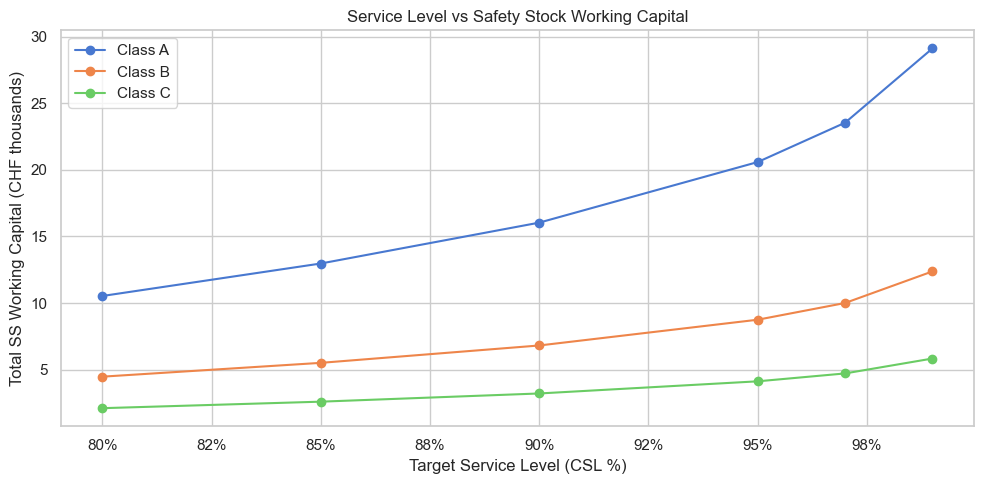

In [8]:
service_levels = [0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
tradeoff_rows = []

for sl in service_levels:
    for abc in ["A", "B", "C"]:
        sub = stats[stats["abc_class"] == abc]
        total_chf = 0
        for _, row in sub.iterrows():
            lt_weeks = row["lead_time_mean"] / 7
            lt_std_weeks = row["lead_time_std"] / 7
            ss = safety_stock_normal(
                sigma_demand=row["std_demand"],
                lead_time=lt_weeks,
                sigma_lead_time=lt_std_weeks,
                avg_demand=row["avg_demand"],
                service_level=sl,
            )
            total_chf += ss * row["unit_cost"]
        tradeoff_rows.append({"service_level": sl, "abc_class": abc, "total_ss_chf": total_chf})

tradeoff = pd.DataFrame(tradeoff_rows)

fig, ax = plt.subplots(figsize=(10, 5))
for abc, grp in tradeoff.groupby("abc_class"):
    ax.plot(grp["service_level"] * 100, grp["total_ss_chf"] / 1000,
            marker="o", label=f"Class {abc}")

ax.set_xlabel("Target Service Level (CSL %)")
ax.set_ylabel("Total SS Working Capital (CHF thousands)")
ax.set_title("Service Level vs Safety Stock Working Capital")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "02c_service_vs_wc_tradeoff.png", dpi=150)
plt.show()

In [9]:
# Cost of the next 5% of service — how much does moving 90->95% cost?
print("Marginal cost of +5pp service level (CHF working capital):")
for abc in ["A", "B", "C"]:
    sub = tradeoff[tradeoff["abc_class"] == abc].set_index("service_level")
    for lo, hi in [(0.85, 0.90), (0.90, 0.95), (0.95, 0.99)]:
        delta = sub.loc[hi, "total_ss_chf"] - sub.loc[lo, "total_ss_chf"]
        print(f"  Class {abc} | {lo*100:.0f}% -> {hi*100:.0f}%: CHF {delta:>10,.0f}")

Marginal cost of +5pp service level (CHF working capital):
  Class A | 85% -> 90%: CHF      3,068
  Class A | 90% -> 95%: CHF      4,547
  Class A | 95% -> 99%: CHF      8,530
  Class B | 85% -> 90%: CHF      1,304
  Class B | 90% -> 95%: CHF      1,933
  Class B | 95% -> 99%: CHF      3,627
  Class C | 85% -> 90%: CHF        615
  Class C | 90% -> 95%: CHF        912
  Class C | 95% -> 99%: CHF      1,711


---
## 7. Business summary and recommendations

In [10]:
# Merge Project 1 forecastability into recommendation
rec = stats.merge(
    p1[["sku", "location", "wape", "forecastability", "bias_direction"]],
    on=["sku", "location"],
    how="left"
).copy()

def recommend(row) -> str:
    if row["ss_status"] == "Under-buffered" and row["abc_class"] == "A":
        return "Increase SS urgently — A class at risk"
    elif row["ss_status"] == "Under-buffered":
        return "Increase SS — stockout risk"
    elif row["ss_status"] == "Over-buffered" and row["abc_class"] == "C":
        return "Reduce SS — free up working capital"
    elif row["ss_status"] == "Over-buffered":
        return "Review SS — potential excess"
    return "On target — no action needed"

rec["recommendation"] = rec.apply(recommend, axis=1)

print("Recommendation summary:")
print(rec["recommendation"].value_counts())

Recommendation summary:
recommendation
On target — no action needed    280
Review SS — potential excess     20
Name: count, dtype: int64


In [11]:
output_cols = [
    "sku", "location", "abc_class", "xyz_class", "segment",
    "avg_demand", "std_demand", "service_target",
    "current_ss", "rec_ss", "ss_delta_units",
    "current_ss_chf", "rec_ss_chf", "ss_delta_chf",
    "doh_current", "doh_rec",
    "ss_status", "recommendation",
]
output = rec[output_cols].sort_values(["abc_class", "ss_delta_chf"])
output.to_csv(OUT / "tables" / "02_safety_stock_results.csv", index=False)
print("Saved results table.")
output.head(12)

Saved results table.


,sku,location,abc_class,xyz_class,segment,avg_demand,std_demand,service_target,current_ss,rec_ss,ss_delta_units,current_ss_chf,rec_ss_chf,ss_delta_chf,doh_current,doh_rec,ss_status,recommendation
85,SKU_B03,Store_Central,A,Y,A/Y,83.91,35.07,0.95,74.00,53.00,-21.00,185.00,132.50,-52.50,6.17,4.42,Over-buffered,Review SS — potential excess
2,SKU_A01,Store_North,A,X,A/X,229.21,40.16,0.95,115.00,85.00,-30.00,143.75,106.25,-37.50,3.51,2.60,Over-buffered,Review SS — potential excess
180,SKU_C02,Store_Central,A,Y,A/Y,23.57,17.13,0.95,28.00,24.00,-4.00,229.60,196.80,-32.80,8.32,7.13,On target,On target — no action needed
93,SKU_B04,Store_South,A,Y,A/Y,61.96,28.99,0.95,67.00,50.00,-17.00,127.30,95.00,-32.30,7.57,5.65,Over-buffered,Review SS — potential excess
101,SKU_B06,Store_East,A,Y,A/Y,45.37,17.46,0.95,50.00,40.00,-10.00,160.00,128.00,-32.00,7.72,6.17,On target,On target — no action needed
152,SKU_B16,Store_North,A,Y,A/Y,33.90,15.23,0.95,33.00,26.00,-7.00,125.40,98.80,-26.60,6.81,5.37,On target,On target — no action needed
56,SKU_A12,Store_East,A,X,A/X,87.48,23.10,0.95,73.00,61.00,-12.00,160.60,134.20,-26.40,5.84,4.88,Over-buffered,Review SS — potential excess
52,SKU_A11,Store_North,A,X,A/X,143.68,35.96,0.95,82.00,68.00,-14.00,147.60,122.40,-25.20,4.00,3.31,Over-buffered,Review SS — potential excess
92,SKU_B04,Store_North,A,Y,A/Y,70.63,27.47,0.95,61.00,48.00,-13.00,115.90,91.20,-24.70,6.05,4.76,Over-buffered,Review SS — potential excess
206,SKU_C07,Store_East,A,Z,A/Z,8.72,7.73,0.95,18.00,16.00,-2.00,216.00,192.00,-24.00,14.46,12.85,On target,On target — no action needed


In [12]:
print("===== SAFETY STOCK SUMMARY =====")
print(f"SKU-locations assessed:          {len(stats)}")
print(f"Under-buffered:                  {(stats['ss_status']=='Under-buffered').sum()}")
print(f"Over-buffered:                   {(stats['ss_status']=='Over-buffered').sum()}")
print(f"On target:                       {(stats['ss_status']=='On target').sum()}")
print()
print(f"Current SS working capital:      CHF {stats['current_ss_chf'].sum():>10,.0f}")
print(f"Recommended SS working capital:  CHF {stats['rec_ss_chf'].sum():>10,.0f}")
print(f"Net WC change:                   CHF {(stats['rec_ss_chf']-stats['current_ss_chf']).sum():>+10,.0f}")
print()
print("These recommended SS values feed directly into Project 3 (Reorder Point).")
print("ROP = avg_demand * lead_time + safety_stock")

===== SAFETY STOCK SUMMARY =====
SKU-locations assessed:          300
Under-buffered:                  0
Over-buffered:                   20
On target:                       280

Current SS working capital:      CHF     31,957
Recommended SS working capital:  CHF     30,002
Net WC change:                   CHF     -1,955

These recommended SS values feed directly into Project 3 (Reorder Point).
ROP = avg_demand * lead_time + safety_stock
